In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('final_cleaned_ipl_dataset.csv')

In [3]:
df.head()

,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,batter,...,method,overs,stage,match_number,team_runs,team_balls,team_wicket,batter_runs,batter_balls,bowler_wicket
0,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,...,Standard,20,Unknown,Unknown,1,1,0,0,1,0
1,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,...,Standard,20,Unknown,Unknown,1,2,0,0,1,0
2,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,...,Standard,20,Unknown,Unknown,2,2,0,0,1,0
3,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,...,Standard,20,Unknown,Unknown,2,3,0,0,2,0
4,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,...,Standard,20,Unknown,Unknown,2,4,0,0,3,0


In [4]:
df.tail()

,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,batter,...,method,overs,stage,match_number,team_runs,team_balls,team_wicket,batter_runs,batter_balls,bowler_wicket
278200,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,2,Shashank Singh,...,Standard,20,Final,Unknown,162,116,7,39,26,0
278201,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,3,Shashank Singh,...,Standard,20,Final,Unknown,168,117,7,45,27,0
278202,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,4,Shashank Singh,...,Standard,20,Final,Unknown,172,118,7,49,28,0
278203,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,5,Shashank Singh,...,Standard,20,Final,Unknown,178,119,7,55,29,0
278204,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,6,Shashank Singh,...,Standard,20,Final,Unknown,184,120,7,61,30,0


In [5]:
df.shape

(278205, 42)

In [6]:
df.columns

Index(['match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bat_pos',
       'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras',
       'runs_total', 'runs_bowler', 'extra_type', 'non_striker', 'wicket_kind',
       'player_out', 'player_of_match', 'match_won_by', 'win_outcome',
       'toss_winner', 'toss_decision', 'venue', 'city', 'season',
       'superover_winner', 'result_type', 'method', 'overs', 'stage',
       'match_number', 'team_runs', 'team_balls', 'team_wicket', 'batter_runs',
       'batter_balls', 'bowler_wicket'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          278205 non-null  int64
 1   date              278205 non-null  str  
 2   match_type        278205 non-null  str  
 3   event_name        278205 non-null  str  
 4   innings           278205 non-null  int64
 5   batting_team      278205 non-null  str  
 6   bowling_team      278205 non-null  str  
 7   over              278205 non-null  int64
 8   ball              278205 non-null  int64
 9   batter            278205 non-null  str  
 10  bat_pos           278205 non-null  int64
 11  runs_batter       278205 non-null  int64
 12  balls_faced       278205 non-null  int64
 13  bowler            278205 non-null  str  
 14  valid_ball        278205 non-null  int64
 15  runs_extras       278205 non-null  int64
 16  runs_total        278205 non-null  int64
 17  runs_bowler       278

In [8]:
df.describe()

,match_id,innings,over,ball,bat_pos,runs_batter,balls_faced,valid_ball,runs_extras,runs_total,runs_bowler,season,overs,team_runs,team_balls,team_wicket,batter_runs,batter_balls,bowler_wicket
count,2.782050e+05,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.00000,278205.000000,278205.000000,278205.0,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000
mean,9.422687e+05,1.482914,9.193839,3.488855,3.612555,1.277378,0.967362,0.963182,0.067971,1.34535,1.320807,2016.710178,20.0,77.110498,58.614637,2.456972,18.327424,14.011211,0.045470
std,3.817198e+05,0.502571,5.681511,1.708263,2.168978,1.651107,0.177687,0.188315,0.343033,1.63762,1.642110,5.248572,0.0,49.957873,34.117619,2.100374,18.578093,11.833930,0.208333
min,3.359820e+05,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2008.000000,20.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483530e+05,1.000000,4.000000,2.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2012.000000,20.0,36.000000,29.000000,1.000000,4.000000,5.000000,0.000000
50%,1.082601e+06,1.000000,9.000000,3.000000,3.000000,1.000000,1.000000,1.000000,0.000000,1.00000,1.000000,2017.000000,20.0,73.000000,58.000000,2.000000,12.000000,11.000000,0.000000
75%,1.304049e+06,2.000000,14.000000,5.000000,5.000000,1.000000,1.000000,1.000000,0.000000,1.00000,1.000000,2022.000000,20.0,113.000000,88.000000,4.000000,27.000000,20.000000,0.000000
max,1.485779e+06,6.000000,19.000000,7.000000,11.000000,6.000000,1.000000,1.000000,7.000000,7.00000,7.000000,2025.000000,20.0,287.000000,121.000000,10.000000,175.000000,73.000000,1.000000


In [9]:
df.isnull().sum()

match_id            0
date                0
match_type          0
event_name          0
innings             0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bat_pos             0
runs_batter         0
balls_faced         0
bowler              0
valid_ball          0
runs_extras         0
runs_total          0
runs_bowler         0
extra_type          0
non_striker         0
wicket_kind         0
player_out          0
player_of_match     0
match_won_by        0
win_outcome         0
toss_winner         0
toss_decision       0
venue               0
city                0
season              0
superover_winner    0
result_type         0
method              0
overs               0
stage               0
match_number        0
team_runs           0
team_balls          0
team_wicket         0
batter_runs         0
batter_balls        0
bowler_wicket       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['batting_team'].nunique()

15

In [12]:
df['batting_team'].unique()

<StringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bengaluru',
         'Chennai Super Kings',                'Punjab Kings',
            'Rajasthan Royals',              'Delhi Capitals',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',      'Rising Pune Supergiant',
               'Gujarat Lions',        'Lucknow Super Giants',
              'Gujarat Titans']
Length: 15, dtype: str

In [13]:
team_matches = pd.concat([
    df[['match_id','batting_team']].rename(columns={'batting_team':'team'}),
    df[['match_id','bowling_team']].rename(columns={'bowling_team':'team'})
])

In [14]:
team_matches = team_matches.drop_duplicates()

In [15]:
team_matches['team'].value_counts()

team
Mumbai Indians                 277
Royal Challengers Bengaluru    270
Delhi Capitals                 267
Kolkata Knight Riders          264
Punjab Kings                   264
Chennai Super Kings            252
Rajasthan Royals               235
Sunrisers Hyderabad            196
Deccan Chargers                 75
Gujarat Titans                  60
Lucknow Super Giants            58
Pune Warriors                   46
Rising Pune Supergiant          30
Gujarat Lions                   30
Kochi Tuskers Kerala            14
Name: count, dtype: int64

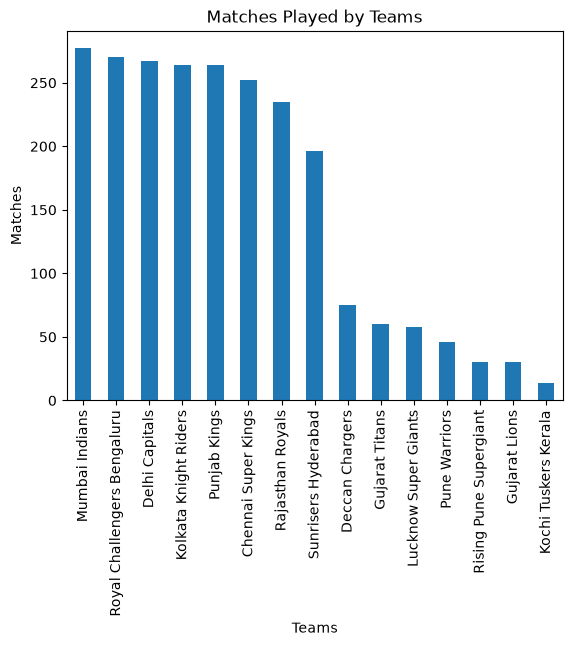

In [16]:
team_matches['team'].value_counts().plot(kind='bar')

plt.title('Matches Played by Teams')

plt.xlabel('Teams')

plt.ylabel('Matches')

plt.show()

In [17]:
top_batters = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

print(top_batters)

batter
V Kohli           8671
RG Sharma         7048
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5235
AB de Villiers    5181
AM Rahane         5032
CH Gayle          4997
Name: runs_batter, dtype: int64


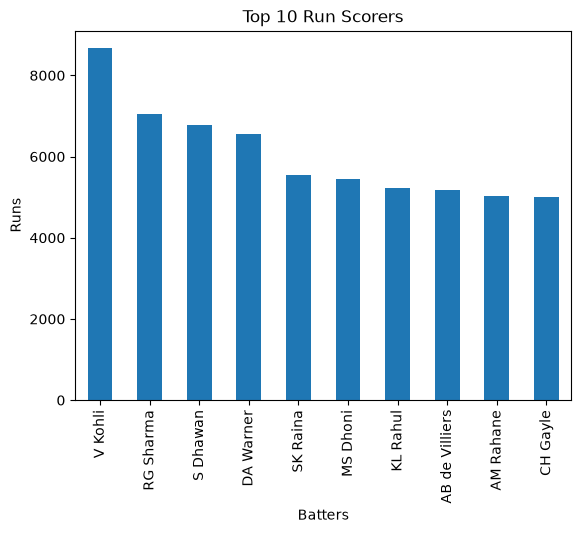

In [18]:
top_batters.plot(kind='bar')

plt.title('Top 10 Run Scorers')

plt.xlabel('Batters')

plt.ylabel('Runs')

plt.show()

In [19]:
top_bowlers = df.groupby('bowler')['bowler_wicket'].sum().sort_values(ascending=False).head(10)

print(top_bowlers)

bowler
YS Chahal     221
B Kumar       198
SP Narine     192
PP Chawla     192
R Ashwin      187
JJ Bumrah     186
DJ Bravo      183
A Mishra      174
RA Jadeja     170
SL Malinga    170
Name: bowler_wicket, dtype: int64


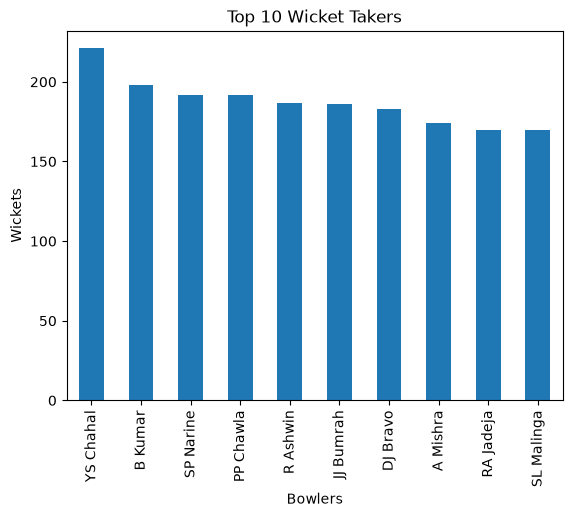

In [20]:
top_bowlers.plot(kind='bar')

plt.title('Top 10 Wicket Takers')

plt.xlabel('Bowlers')

plt.ylabel('Wickets')

plt.show()

In [21]:
venue_runs = df.groupby('venue')['runs_total'].sum().sort_values(ascending=False).head(10)

print(venue_runs)

venue
Wankhede Stadium                       41321
M Chinnaswamy Stadium                  32399
Eden Gardens                           32224
Arun Jaitley Stadium                   31799
MA Chidambaram Stadium                 28605
Rajiv Gandhi International Stadium     26392
Sawai Mansingh Stadium                 20359
Punjab Cricket Association Stadium     19864
Narendra Modi Stadium                  15539
Dubai International Cricket Stadium    14450
Name: runs_total, dtype: int64


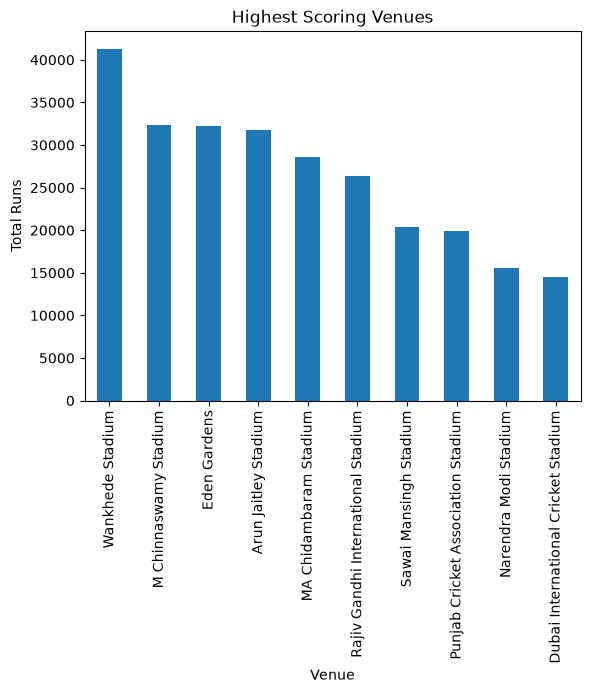

In [22]:
venue_runs.plot(kind='bar')

plt.title('Highest Scoring Venues')

plt.xlabel('Venue')

plt.ylabel('Total Runs')

plt.show()

In [23]:
df['toss_decision'].value_counts()

toss_decision
field    181679
bat       96526
Name: count, dtype: int64

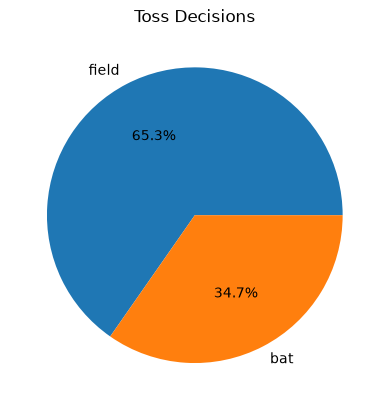

In [24]:
df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Toss Decisions')

plt.show()

In [25]:
season_runs = df.groupby('season')['runs_total'].sum()

print(season_runs)

season
2008    17937
2009    16353
2010    18883
2011    21154
2012    22453
2013    22602
2014    18931
2015    18353
2016    18862
2017    18786
2018    19901
2019    19434
2020    19416
2021    18637
2022    24395
2023    25688
2024    25971
2025    26527
Name: runs_total, dtype: int64


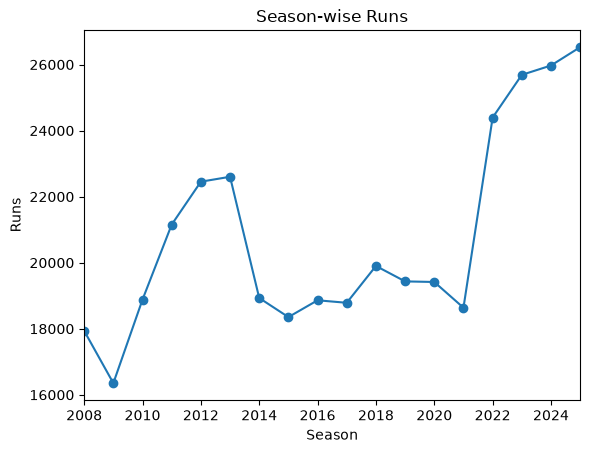

In [26]:
season_runs.plot(kind='line', marker='o')

plt.title('Season-wise Runs')

plt.xlabel('Season')
plt.xlim(2008,2025)
plt.margins(x=0)

plt.ylabel('Runs')

plt.show()

In [27]:
pom_df = df.drop_duplicates(subset=['match_id'])

In [28]:
pom_count = pom_df['player_of_match'].value_counts()

In [29]:
pom_count = pom_df['player_of_match'].value_counts().head(10)

In [30]:
pom_count.head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           19
MS Dhoni          18
DA Warner         18
SP Narine         17
SR Watson         16
YK Pathan         16
RA Jadeja         16
Name: count, dtype: int64

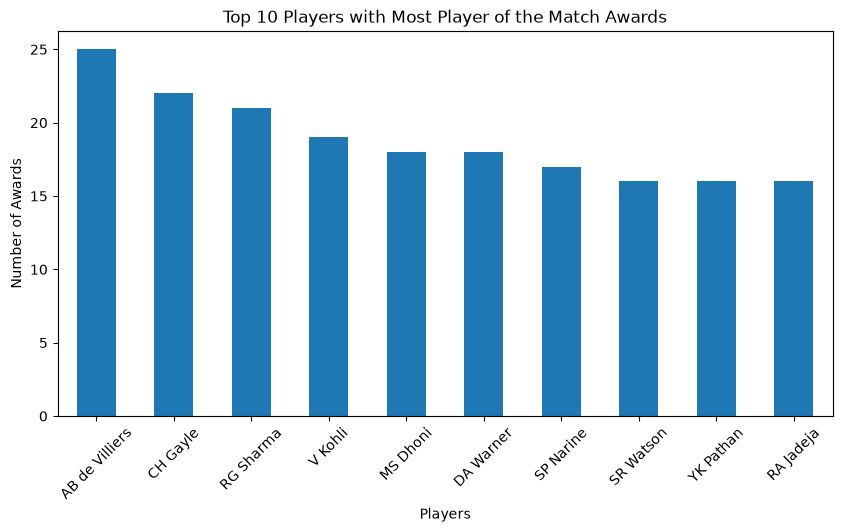

In [31]:
plt.figure(figsize=(10,5))

pom_count.plot(kind='bar')

plt.title('Top 10 Players with Most Player of the Match Awards')
plt.xlabel('Players')
plt.ylabel('Number of Awards')

plt.xticks(rotation=45)

plt.show()

In [32]:
df.to_csv('eda_ready_ipl_dataset.csv', index=False)

In [ ]:
df.to_excel('eda_ready_ipl_dataset.xlsx',index=False)